['run', 'luminosityBlock', 'event', 'nboostedTau', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'boostedTau_neutralIso', 'boostedTau_phi', 'boostedTau_photonsOutsideSignalCone', 'boostedTau_pt', 'boostedTau_puCorr', 'boostedTau_rawAntiEle2018', 'boostedTau_rawIso', 'boostedTau_rawIsodR03', 'boostedTau_rawMVAnewDM2017v2', 'boostedTau_rawMVAoldDM2017v2', 'boostedTau_rawMVAoldDMdR032017v2', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_idMVAoldDMdR032017v2', 'CaloMET_phi', 'CaloMET_pt', 'CaloMET_sumEt', 'ChsMET_phi', 'ChsMET_pt', 'ChsMET_sumEt', 'nCorrT1METJet', 'CorrT1METJet_area', 'CorrT1METJet_eta', 'CorrT1METJet_muonSubtrFactor', 'CorrT1METJet_phi', 'CorrT1METJet_rawPt', 'DeepMETResolutionTune_phi', 'DeepM

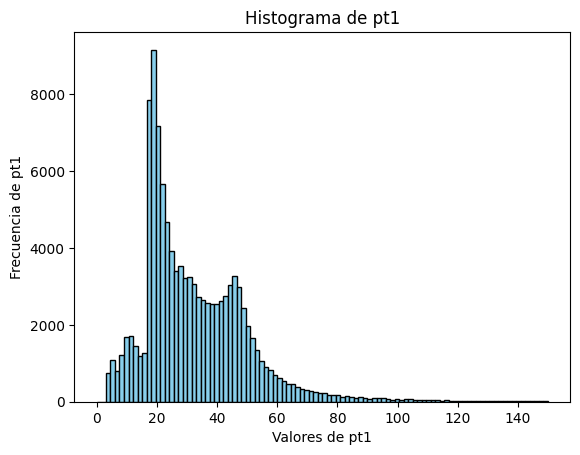

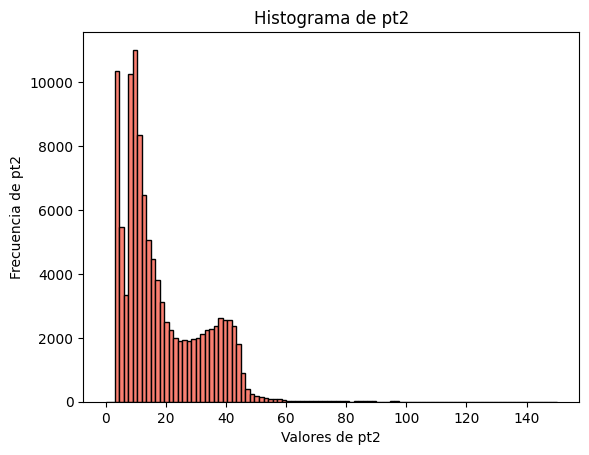

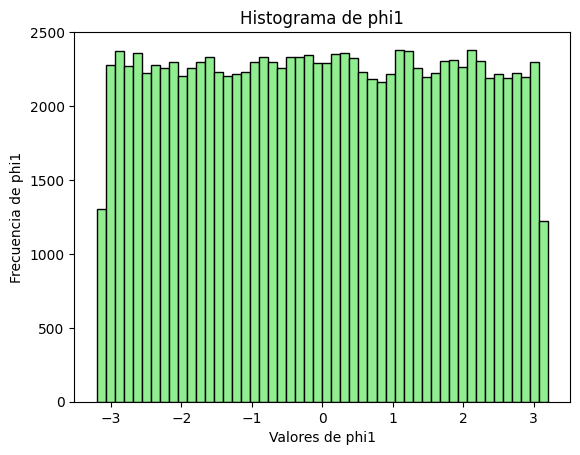

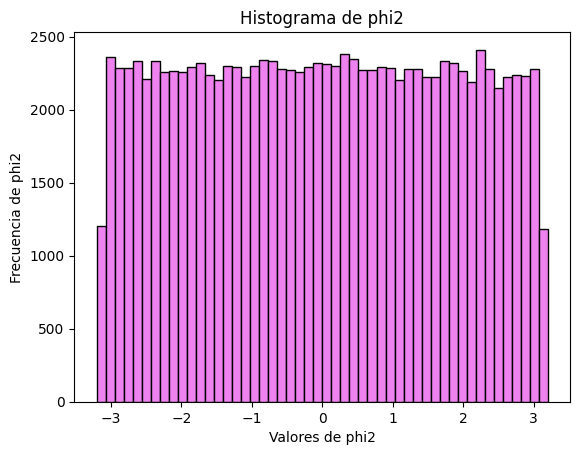

Eventos totales: 111783
Eventos filtrados > 20 : 39177
pt1    float64
pt2    float64
dtype: object
          pt1        pt2
7   20.786207  14.875778
11  24.440779  18.830746
18  19.103994  13.704683
19  27.273527  16.987825
20  20.190704   8.850918
Eventos totales: 111783
Eventos filtrados < 2.1 : 96666
eta1    float64
eta2    float64
dtype: object
        eta1      eta2
7  -0.548706 -1.010254
11 -0.711182  1.950439
18 -1.678223 -1.702393
19  0.603394  0.603271
20  0.241577  0.160431
Eventos totales: 111783
Eventos filtrados < 2.5 : 97754
iso1    float64
iso2    float64
dtype: object
        iso1      iso2
7   0.042406  0.245808
11  0.031759  0.081182
18  0.382183  0.281527
19  0.024396  0.039167
20  0.836302  1.995143
Masa invariante :
float64
7     36.091256
11    86.308212
18     1.262726
19     0.199710
20     1.568175
23     3.134892
27     1.624234
33    86.641350
35    86.337057
36    93.738046
Name: M, dtype: float64
Masa invariante calculada para eventos de carga opuesta.
7   

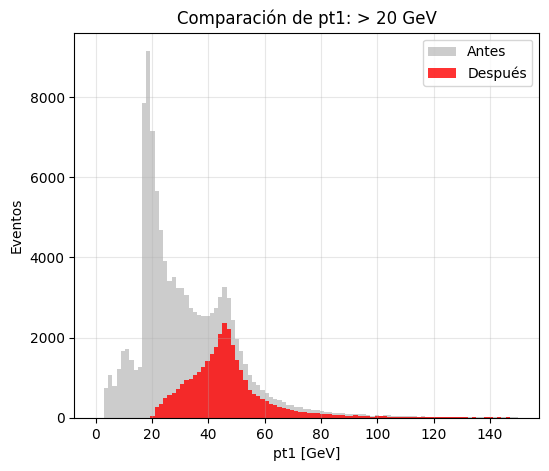

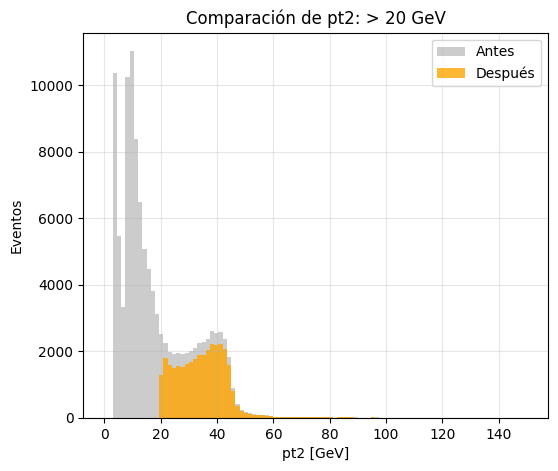

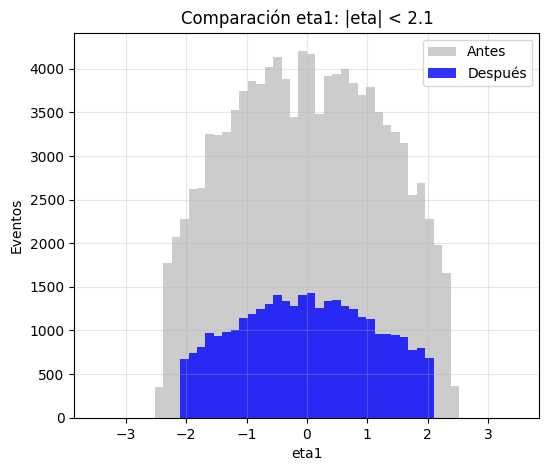

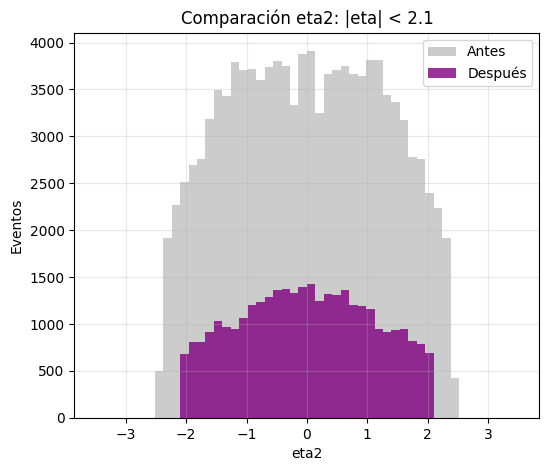

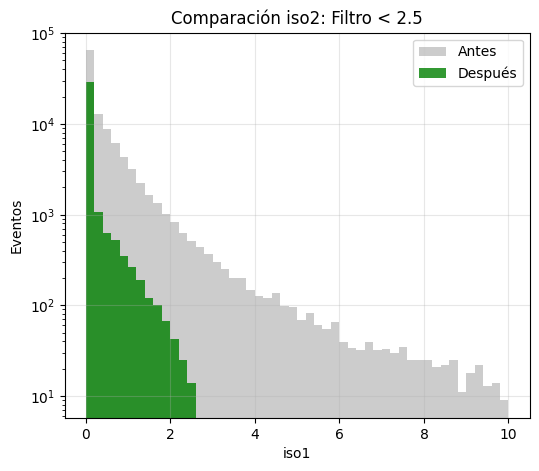

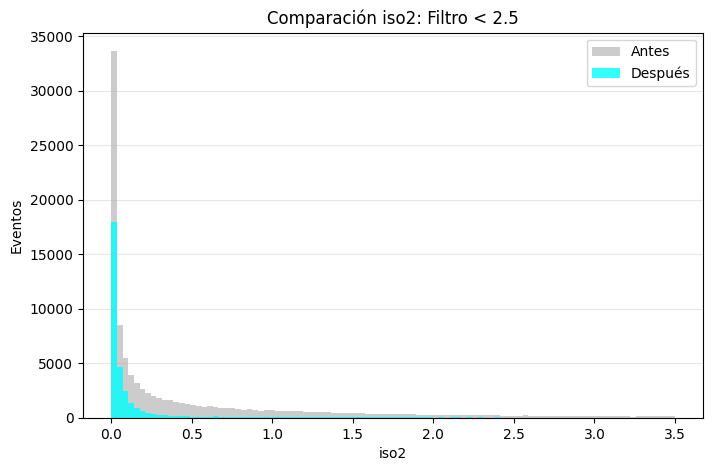

TABLA DE FLUJO DE CORTES
  Corte aplicado  Eventos Restantes  Aceptancia
0    Sin filtros             111783  100.000000
1    pT > 20 GeV              39177   35.047369
2    |eta| < 2.1              33445   29.919576
3      iso < 2.5              32656   29.213744

El corte más significativo es: pt (eliminó 72606 eventos)
El corte menos significativo es: iso (eliminó 789 eventos)


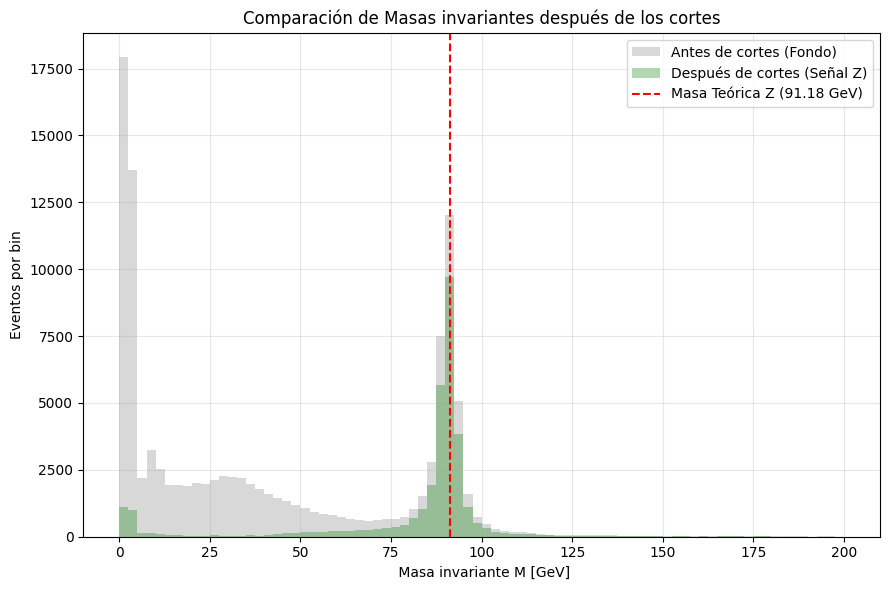

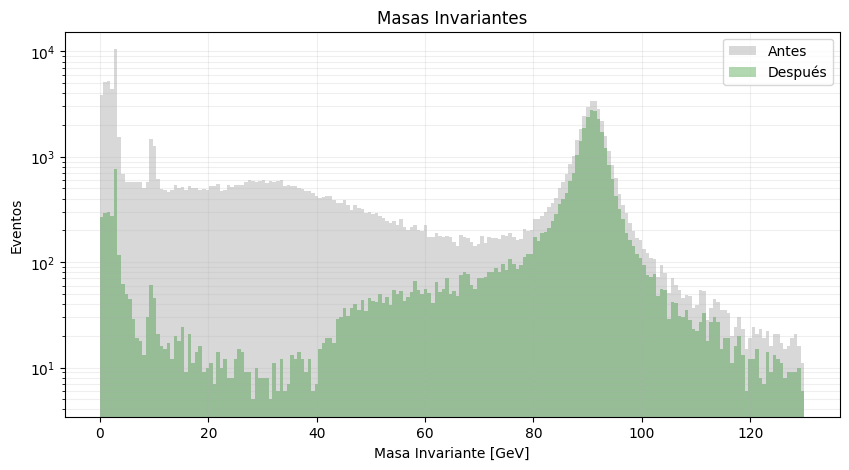

In [1]:
import numpy as np
from pathlib import Path
import math
import matplotlib.pyplot as plt
import pandas as pd
import uproot

file = uproot.open("C:/Users/HP/Documents/Practica Profesional/Datos root/muon_simple.root")
tree = file['Events']

# Listar ramas (variables físicas)

print(tree.keys())
tree.keys()
print (['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge'])

# Extraer los datos del árbol a un DataFrame de Pandas (crea una tabla donde cada celda puede contener una lista de muones)

df = tree.arrays(['Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_charge','Muon_pfRelIso04_all'], library="pd")

# Buscamos pares de muones para el decaemiento del bosón z

df_2mu = df[df["Muon_pt"].apply(len) == 2].copy()
print(df_2mu["Muon_charge"].head())

# Dividimos las listas en columnas individuales para Múon 1 y 2 

df_2mu['pt1'] = df_2mu['Muon_pt'].apply(lambda x: x[0])
df_2mu['pt2'] = df_2mu['Muon_pt'].apply(lambda x: x[1])

df_2mu['eta1'] = df_2mu['Muon_eta'].apply(lambda x: x[0])
df_2mu['eta2'] = df_2mu['Muon_eta'].apply(lambda x: x[1])

df_2mu['phi1'] = df_2mu['Muon_phi'].apply(lambda x: x[0])
df_2mu['phi2'] = df_2mu['Muon_phi'].apply(lambda x: x[1])

df_2mu['charge1'] = df_2mu['Muon_charge'].apply(lambda x: x[0])
df_2mu['charge2'] = df_2mu['Muon_charge'].apply(lambda x: x[1])

df_2mu['iso1'] = df_2mu['Muon_pfRelIso04_all'].apply(lambda x: x[0])
df_2mu['iso2'] = df_2mu['Muon_pfRelIso04_all'].apply(lambda x: x[1])



# Mostrar las nuevas columnas ("pt1","pt2","eta1","eta2","phi1","phi2","charge1","charge2")

print(df_2mu[["pt1","pt2","eta1","eta2","phi1","phi2","charge1","charge2","iso1","iso2"]].head())

# Valores únicos de las cargas

print("Valores únicos en charge1:", df_2mu["charge1"].unique())
print("Valores únicos en charge2:", df_2mu["charge2"].unique())

# Filtrar pares de muones con cargas opuestas

df_pairs = df_2mu[(df_2mu["charge1"] * df_2mu["charge2"]) == -1]

# Verificación de eventos totales con dos muones 

print("Eventos con dos muones:", len(df_2mu))
print("Eventos con dos muones y cargas opuestas:", len(df_pairs))

# Medidas de tendencia central (pt1,pt2,phi1,phi2)

media_pt1 = df_pairs['pt1'].mean()
print("Media de pt1:", media_pt1)
media_pt2 = df_pairs['pt2'].mean()
print("Media de pt2:", media_pt2)
media_phi1 = df_pairs['phi1'].mean()
print("Media de phi1:", media_phi1)
media_phi2 = df_pairs['phi2'].mean()
print("Media de phi2:", media_phi2)

mediana_pt1 = df_pairs['pt1'].median()
print("Mediana de pt1:", mediana_pt1)
mediana_pt2 = df_pairs['pt2'].median()
print("Mediana de pt2:", mediana_pt2)
mediana_phi1 = df_pairs['phi1'].median()
print("Mediana de phi1:", mediana_phi1)
mediana_phi2 = df_pairs['phi2'].median()
print("Mediana de phi2:", mediana_phi2)

moda_pt1 = df_pairs['pt1'].mode()[0]
print("Moda de pt1:", moda_pt1)
moda_pt2 = df_pairs['pt2'].mode()[0]
print("Moda de pt2:", moda_pt2)
moda_phi1 = df_pairs['phi1'].mode()[0]
print("Moda de phi1:", moda_phi1)
moda_phi2 = df_pairs['phi2'].mode()[0]
print("Moda de phi2:", moda_phi2)

# Medidas de dispersion (pt1,pt2,phi1,phi2)

varianza_pt1 = df_pairs['pt1'].var()
print("Varianza de pt1:", varianza_pt1)
varianza_pt2 = df_pairs['pt2'].var()
print("Varianza de pt2:", varianza_pt2)
varianza_phi1 = df_pairs['phi1'].var()
print("Varianza de phi1:", varianza_phi1)
varianza_phi2 = df_pairs['phi2'].var()
print("Varianza de phi2:", varianza_phi2)

desviacion_pt1 = df_pairs['pt1'].std()
print("Desviacion estandar pt1:", desviacion_pt1)
desviacion_pt2 = df_pairs['pt2'].std()
print("Desviacion estandar pt2:", desviacion_pt2)
desviacion_phi1 = df_pairs['phi1'].std()
print("Desviacion estandar phi1:", desviacion_phi1)
desviacion_phi2 = df_pairs['phi2'].std()
print("Desviacion estandar phi2", desviacion_phi2)

# MEdidads de posición (Rango y  Cuartiles)
rango_pt1 = df_pairs['pt1'].max() - df_pairs['pt1'].min()
print("Rango de pt1:", rango_pt1)
rango_pt2 = df_pairs['pt2'].max() - df_pairs['pt2'].min()
print("Rango de pt2:", rango_pt2)
rango_phi1 = df_pairs['phi1'].max() - df_pairs['phi1'].min()
print("Rango de phi1:", rango_phi1)
rango_phi2 = df_pairs['phi2'].max() - df_pairs['phi2'].min()
print("Rango de phi2:", rango_phi2)

cuartiles_pt1 = df_pairs['pt1'].quantile([0.25,0.50,0.75])
print("cuartiles de pt1:", cuartiles_pt1)
cuartiles_pt2 = df_pairs['pt2'].quantile([0.25,0.50,0.75])
print("cuartiles de pt2:", cuartiles_pt2)
cuartiles_phi1 = df_pairs['phi1'].quantile([0.25,0.50,0.75])
print("cuartiles de phi1:", cuartiles_phi1)
cuartiles_phi2 = df_pairs['phi2'].quantile([0.25,0.50,0.75])
print("cuartiles de phi2:", cuartiles_phi2)

# Histograma pt1 y pt2

plt.hist(df_pairs['pt1'], bins=100, range=(0, 150), color='skyblue', edgecolor='black')
plt.title('Histograma de pt1')
plt.xlabel('Valores de pt1')
plt.ylabel('Frecuencia de pt1')
plt.show()

plt.hist(df_pairs['pt2'], bins=100, range=(0, 150), color='salmon', edgecolor='black')
plt.title('Histograma de pt2')
plt.xlabel('Valores de pt2')
plt.ylabel('Frecuencia de pt2')
plt.show()

# Histograma phi1 y phi2

plt.hist(df_pairs['phi1'], bins=50, range=(-3.2, 3.2), color='lightgreen', edgecolor='black')
plt.title('Histograma de phi1')
plt.xlabel('Valores de phi1')
plt.ylabel('Frecuencia de phi1')
plt.show()

plt.hist(df_pairs['phi2'], bins=50, range=(-3.2, 3.2), color='violet', edgecolor='black')
plt.title('Histograma de phi2')
plt.xlabel('Valores de phi2')
plt.ylabel('Frecuencia de phi2')
plt.show()

# Filtrar de forma que solo se tengan eventos con pT > 20 (para ambas partículas, muón 1 y muón 2)

mask_pt = (df_pairs["pt1"] > 20) & (df_pairs["pt2"] > 20)
print("Eventos totales:", len(df_pairs))
print("Eventos filtrados > 20 :", mask_pt.sum())

print(df_pairs[["pt1","pt2"]].dtypes)
print(df_pairs[["pt1","pt2"]].head())

# Filtrar para obtener eventos con |eta|<2.1 (para ambos, eta1 y eta2)

mask_eta = (df_pairs["eta1"].abs() < 2.1) & (df_pairs["eta2"].abs() < 2.1)
print("Eventos totales:", len(df_pairs))
print("Eventos filtrados < 2.1 :", mask_eta.sum())

print(df_pairs[["eta1","eta2"]].dtypes)
print(df_pairs[["eta1","eta2"]].head())

# Filtrar para obtener eventos con iso<2.5 (para ambos, iso1 e iso2).

mask_pt = (df_pairs["iso1"] < 2.5) & (df_pairs["iso2"] < 2.5)
print("Eventos totales:", len(df_pairs))
print("Eventos filtrados < 2.5 :", mask_pt.sum())

print(df_pairs[["iso1","iso2"]].dtypes)
print(df_pairs[["iso1","iso2"]].head())

# Usando las variables de la muestra, calcular y agregar una nueva columna llamada "M"


df_pairs["M"] = M = np.sqrt(2 * df_pairs["pt1"] * df_pairs["pt2"] * (np.cosh(df_pairs["eta1"] - df_pairs["eta2"]) - np.cos(df_pairs["phi1"] - df_pairs["phi2"])))

# Verificamos la nueva columna 

print("Masa invariante :")
print(df_pairs["M"].dtypes)
print(df_pairs["M"].head(10))

# Masa invariante antes del corte

m2_antes = 2 * df_pairs["pt1"] * df_pairs["pt2"] * (np.cosh(df_pairs["eta1"] - df_pairs["eta2"]) - np.cos(df_pairs["phi1"] - df_pairs["phi2"]))
df_pairs["M"] = np.sqrt(m2_antes)
print("Masa invariante calculada para eventos de carga opuesta.")



# Aplicar los filtros para crear un DataFrame filtrado

mask_pt = (df_pairs["pt1"] > 20) & (df_pairs["pt2"] > 20)
mask_eta = (df_pairs["eta1"].abs() < 2.1) & (df_pairs["eta2"].abs() < 2.1)
mask_iso = (df_pairs["iso1"] < 2.5) & (df_pairs["iso2"] < 2.5)

df_filtrado = df_pairs[mask_pt & mask_eta & mask_iso].copy()
print(mask_pt.head())

# Lista de variables que queremos comparar

variables = ['pt1', 'eta1', 'iso1']
colores = ['red', 'blue', 'green']

# Comparación de momento transversal pt1 y pt2 (Rango a 150 GeV)

plt.figure(figsize=(6,5))
plt.hist(df_pairs['pt1'], bins=100, range=(0,150), alpha=0.4, label='Antes', color='gray')
plt.hist(df_filtrado['pt1'], bins=100, range=(0,150), alpha=0.8, label='Después', color='red')
plt.title('Comparación de pt1: > 20 GeV')
plt.xlabel('pt1 [GeV]')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(df_pairs['pt2'], bins=100, range=(0, 150), alpha=0.4, label='Antes', color='gray')
plt.hist(df_filtrado['pt2'], bins=100, range=(0, 150), alpha=0.8, label='Después', color='orange')
plt.title('Comparación de pt2: > 20 GeV')
plt.xlabel('pt2 [GeV]')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparación de eta1 y eta2 (Pseudorapidez)

plt.figure(figsize=(6,5))
plt.hist(df_pairs['eta1'], bins=50, range=(-3.5,3.5), alpha=0.4, label='Antes', color='gray')
plt.hist(df_filtrado['eta1'], bins=50, range=(-3.5,3.5), alpha=0.8, label='Después', color='blue')
plt.title('Comparación eta1: |eta| < 2.1')
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(df_pairs['eta2'], bins=50, range=(-3.5,3.5), alpha=0.4, label='Antes', color='gray')
plt.hist(df_filtrado['eta2'], bins=50, range=(-3.5,3.5), alpha=0.8, label='Después', color='purple')
plt.title('Comparación eta2: |eta| < 2.1')
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparación de iso1 e iso2 (Aislamiento)

plt.figure(figsize=(6,5))
plt.hist(df_pairs['iso1'], bins=50, range=(0,10), alpha=0.4, label='Antes', color='gray')
plt.hist(df_filtrado['iso1'], bins=50, range=(0,10), alpha=0.8, label='Después', color='green')
plt.yscale('log')
plt.title('Comparación iso2: Filtro < 2.5')
plt.xlabel('iso1')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_pairs['iso2'], bins=100, range=(0, 3.5), alpha=0.4, label='Antes', color='gray')
plt.hist(df_filtrado['iso2'], bins=100, range=(0, 3.5), alpha=0.8, label='Después', color='cyan')
plt.title('Comparación iso2: Filtro < 2.5')
plt.xlabel('iso2')
plt.ylabel('Eventos')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 1. Aplicamos los filtros en orden secuencial

n_total = len(df_pairs)

# Corte 1: pT > 20

mask_pt = (df_pairs['pt1'] > 20) & (df_pairs['pt2'] > 20)
df_pairs_paso1 = df_pairs[mask_pt]
n_pt = len(df_pairs_paso1)

# Corte 2: |eta| < 2.1

mask_eta = (df_pairs_paso1['eta1'].abs() < 2.1) & (df_pairs_paso1['eta2'].abs() < 2.1)
df_pairs_paso2 = df_pairs_paso1[mask_eta]
n_eta = len(df_pairs_paso2)

# Corte 3: iso < 2.5

mask_iso = (df_pairs_paso2['iso1'] < 2.5) & (df_pairs_paso2['iso2'] < 2.5)
df_pairs_paso3 = df_pairs_paso2[mask_iso]
n_iso = len(df_pairs_paso3)

# Tabla Cutflow

data_flujo = {
    'Corte aplicado': ['Sin filtros', 'pT > 20 GeV', '|eta| < 2.1', 'iso < 2.5'],
    'Eventos Restantes': [n_total, n_pt, n_eta, n_iso],
    'Aceptancia': [100, (n_pt/n_total)*100, (n_eta/n_total)*100, (n_iso/n_total)*100]
}

tabla_flujo = pd.DataFrame(data_flujo)
print("TABLA DE FLUJO DE CORTES")
print(tabla_flujo)

# Corte más y menos significativo (por pérdida absoluta)

perdida_pt = n_total - n_pt
perdida_eta = n_pt - n_eta
perdida_iso = n_eta - n_iso

perdidas = {'pt': perdida_pt, 'eta': perdida_eta, 'iso': perdida_iso}
mas_sig = max(perdidas, key=perdidas.get)
menos_sig = min(perdidas, key=perdidas.get)

print(f"\nEl corte más significativo es: {mas_sig} (eliminó {perdidas[mas_sig]} eventos)")
print(f"El corte menos significativo es: {menos_sig} (eliminó {perdidas[menos_sig]} eventos)")

# Gráfica de la masa invariante

plt.figure(figsize=(9, 6))
plt.hist(df_pairs["M"], bins=80, range= (0, 200 ), alpha=0.3,
         label="Antes de cortes (Fondo)", color="gray")
plt.hist(df_filtrado["M"], bins=80, range=(0, 200), alpha=0.3,
         label="Después de cortes (Señal Z)", color="green", histtype='stepfilled')
plt.title("Comparación de Masas invariantes después de los cortes")
plt.xlabel(" Masa invariante M [GeV]")
plt.ylabel('Eventos por bin')
plt.axvline(91.18, color='red', linestyle='--', linewidth=1.5, label='Masa Teórica Z (91.18 GeV)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Graficamos la comparación

plt.figure(figsize=(10,5))
plt.hist(df_pairs["M"], bins=200, range=(0, 130), alpha=0.3, color='gray', label='Antes')
plt.hist(df_filtrado["M"], bins=200, range=(0, 130), alpha=0.3, color='green', label='Después')

plt.yscale('log')
plt.title('Masas Invariantes')
plt.xlabel('Masa Invariante [GeV]')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()






In [3]:
import uproot

# Ver ekl número de eventos "sucio"
path = r"C:\Users\HP\Documents\Practica Profesional\Datos root\muon_simple.root"

with uproot.open(path) as file:
    tree = file["Events"]
    print(f"Número total de entradas en el archivo: {tree.num_entries}")

Número total de entradas en el archivo: 282708
